In [5]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mplc
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize, LinearSegmentedColormap
from matplotlib.ticker import LogFormatter
from matplotlib.ticker import ScalarFormatter
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
%matplotlib inline
import seaborn as sns
import os
import random
import pyreadr
import csv

from scipy.stats import kstest, norm

from scipy.stats import gaussian_kde, binned_statistic
from scipy.stats import skew, kurtosis


# import descartes
import geopandas as gpd
import geodatasets
import shapely.geometry
from scipy.optimize import curve_fit
from sklearn.metrics import mean_absolute_error
import osmnx as ox
import pickle
from scipy.stats import pearsonr, entropy

import folium

from scipy.stats import gaussian_kde
from scipy.stats import binned_statistic
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error
from scipy import interpolate
import statsmodels.api as sm
import scipy.stats as stats
from scipy.stats import kstest, anderson, norm, shapiro

from scipy.stats import pearsonr

%matplotlib inline

import networkx as nx
import collections

import rioxarray

import warnings
warnings.filterwarnings('ignore')


import os


# Define the power-law function
def power_law(x, a, b):
    return a * np.power(x, b)

# Define the linear function
def linear(x, a, b):
    return a + b * x

os.chdir(r'C:\Users\mduran\Desktop\PhD- Patterns and Dynamics in Urban Networks\1- DATA POLLUTION - Scaling laws, pdfs\RESULTS_GLOBAL') 

In [6]:
#STEP RESOLUTION DEGREES TO meters

from math import radians, cos, sin, asin, sqrt

def haversine(lon1, lat1, lon2, lat2):

    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])

    # haversine formula 
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371000 # Radius of earth in meters
    return c * r 

haversine(1,1,1.01,1)

1111.779911186028

# SIMULATION

## CLIMATE VARIABLES

Noise sigma: 0.0 | KS test p-value: 0.000
Noise sigma: 0.3 | KS test p-value: 0.000


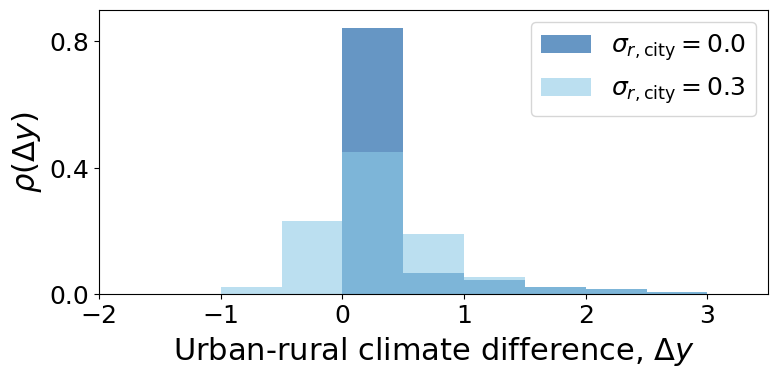

In [4]:
# Parameters
T0 = 2.5        # Peak temperature at the city center
sigma_r = 5     # Controls the rate of temperature decay
R = 25          # Radius of the city
n_samples = 2500

# Sample the deterministic temperature field
rs = []
Td = []  # Deterministic temperatures without noise
for i in range(n_samples):
    # Sample r uniformly in area: r = R*sqrt(u), where u ~ U(0,1)
    r = R * np.sqrt(np.random.uniform(0, 1))
    T = T0 * np.exp(-r**2 / (2 * sigma_r**2))
    rs.append(r)
    Td.append(T)

# Define constant bin edges across all noise levels
bins = np.linspace(-2.5, 4, 14)

# Define noise levels and assign a color to each
noise_levels = [0, 0.35]
colors = ['#00509d', '#8ecae6']

plt.figure(figsize=(8, 4))

for sigma_noise, color in zip(noise_levels, colors):
    # Add Gaussian noise to the deterministic temperatures
    noise = np.random.normal(loc=0, scale=sigma_noise, size=n_samples)
    T_obs = np.array(Td) + noise + 0.15
    
    # Compute mean and std of the noisy temperatures
    mu = np.mean(T_obs)
    std = np.std(T_obs)
    
    plt.hist(T_obs, bins=bins, weights=np.ones_like(T_obs) / n_samples, alpha=0.6, 
             label=rf"$\sigma_{{r,\mathrm{{city}}}} = {sigma_noise:.1f}$", color=color)
    
    # KS test
    D, p_value = kstest(T_obs, 'norm', args=(mu, std))
    print(f"Noise sigma: {sigma_noise:.1f} | KS test p-value: {p_value:.3f}")

plt.xlabel(r'Urban-rural climate difference, $\Delta y$', fontsize=22, labelpad=5)
plt.ylabel(r'$\rho(\Delta y)$', fontsize=22) #Density
plt.yticks([0,0.4,0.8])
plt.tick_params(axis='x', labelsize=18)
plt.tick_params(axis='y', labelsize=18)
plt.legend(fontsize=18, loc='upper right')

plt.tight_layout(pad=1.5)
plt.xlim(-2, 3.5)
plt.ylim(0, 0.9)

# plt.savefig('climate_variables_model_with_whitenoise_label.svg', format='svg', dpi=600, bbox_inches='tight')
plt.show()


## STREET NETWORK

σ_log=0.0  →  KS p‑value = 0.000
σ_log=1.0  →  KS p‑value = 0.000


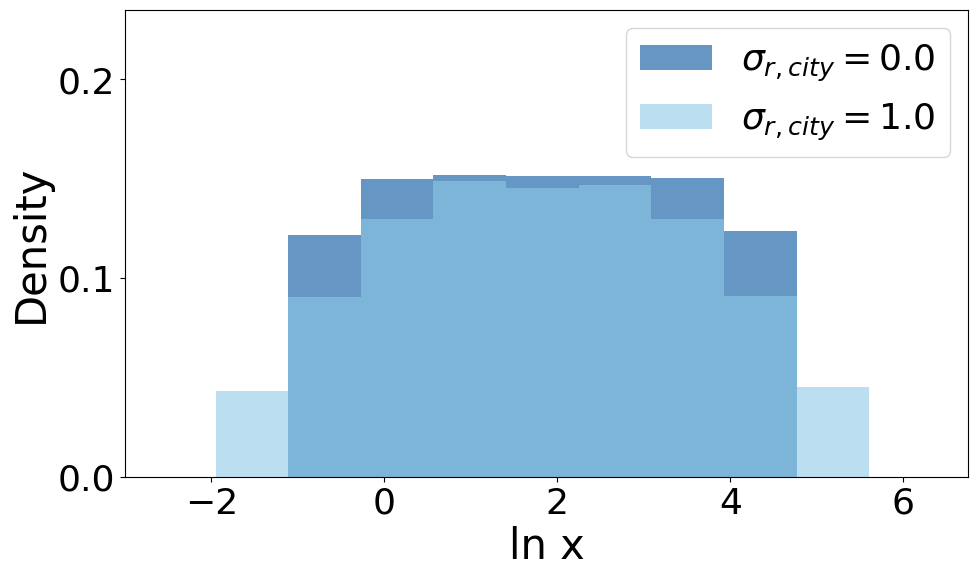

In [3]:
# Parameters 
n0   = 100      # central amplitude
lam  = 7.5      # decay length  λ  (km)
R    = 25       # city radius   (km)
N    = 50000     # samples
sigma_ln_levels = [0.0, 1.0]      # multiplicative noise strengths
colors = ['#00509d', '#8ecae6']

# Deterministic ln n(r)
r = R * np.sqrt(np.random.rand(N))
y_det = np.log(n0) - r**2 / (2*lam**2)   # y = ln n

# Common histogram bins (log‑space)
bins = np.linspace(y_det.min()-1, y_det.max()+1, 10)

plt.figure(figsize=(10, 6))

for s_ln, c in zip(sigma_ln_levels, colors):
    # Add white noise in log‑space
    y_obs = y_det + np.random.normal(0, s_ln, size=N)

    plt.hist(y_obs, bins=bins, weights=np.ones_like(y_obs)/N,
             alpha=0.6, color=c, label=fr"$\sigma_{{r,city}} = {s_ln:.1f}$")

    mu, sd = norm.fit(y_obs)
    D, p_val = kstest(y_obs, 'norm', args=(mu, sd))
    print(f"σ_log={s_ln:.1f}  →  KS p‑value = {p_val:.3f}")

plt.xlabel('ln x', fontsize=30)
plt.ylabel('Density', fontsize=30)
plt.tick_params(axis='x', labelsize=26)
plt.tick_params(axis='y', labelsize=26)
plt.xlim(-3,6.75)
plt.ylim(0,0.235)
plt.yticks([0, 0.1, 0.2])
plt.legend(fontsize=26, loc='upper right')
plt.tight_layout(pad=1.5)
# plt.savefig('street_network_model_with_whitenoise_label.svg', format='svg', dpi=600, bbox_inches='tight')
plt.show()


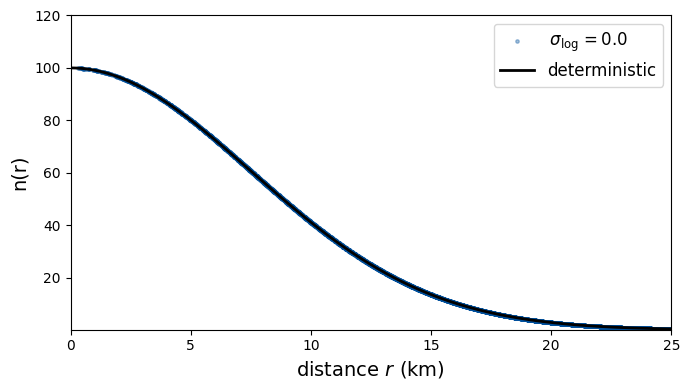

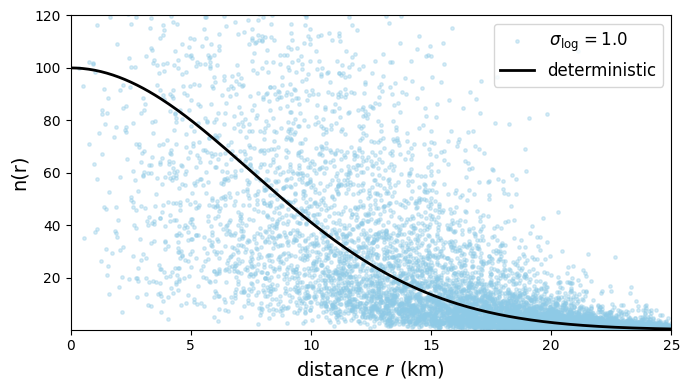

In [4]:
n0, lam, R = 100, 7.5, 25          # amplitude, decay length, radius (km)
N          = 10_000                # samples
sig_ln_set = [0.0, 1.0]            # multiplicative noise strengths
colors     = ['#00509d', '#8ecae6']

# Sample radii uniformly in area
r = R * np.sqrt(np.random.rand(N))

# Deterministic profile in linear space
n_det = n0 * np.exp(-r**2 / (2*lam**2))

# For a smooth reference curve
r_smooth = np.linspace(0, R, 300)
n_curve  = n0 * np.exp(-r_smooth**2 / (2*lam**2))

for s_ln, col in zip(sig_ln_set, colors):

    plt.figure(figsize=(7, 4))
    
    # multiplicative white noise  (additive in log space)
    n_obs = n_det * np.exp(np.random.normal(0, s_ln, size=N))
    plt.scatter(r, n_obs, s=6, alpha=0.35, color=col,
                label=rf'$\,\sigma_{{\log}}={s_ln:.1f}$')

    # deterministic curve
    plt.plot(r_smooth, n_curve, 'k-', lw=2, label='deterministic')

    plt.xlabel('distance $r$ (km)', fontsize=14)
    plt.ylabel('n(r)', fontsize=14)                    
    plt.xlim(0, R); plt.ylim(0.1, n0*1.2)
    plt.legend(fontsize=12)
    plt.tight_layout()
    # plt.savefig('decay_lognormal_example.svg', format='svg', dpi=600, bbox_inches='tight')
    plt.show()


# REAL DATA

In [ ]:
net_type = 'drive'

T_type = 'mean'

POPULATION = 'no'

PM = '25'

In [ ]:
cities = [
    'Barcelona', 'Montpellier', 'Rome', 'Naples', 'Porto', 'Sevilla', 'Alicante', 'Valencia', 'Bologna', 'Padua', 'Turin',
    'Madrid', 'Murcia', 'Genoa', 'Milan', 'Lisbon', 'Palma_de_Mallorca', 'Split','Marseille', 'Palermo','Nice', 'Malaga', 'Bari', 

    'Antwerp', 'Amsterdam', 'Brussels', 'London', 'Paris', 'Luxembourg', 'Rotterdam', 'Lille', 'Basel', 'Birmingham', 'Nantes', 'Strasbourg',
    'Zurich', 'Frankfurt', 'Vienna', 'Munich', 'Bratislava', 'Prague', 'Geneva', 'Bordeaux', 'Utrecht', 
    'Liege', 'Bilbao', 'Charleroi', 'Wroclaw', 'Leipzig', 'Berlin', 'Hamburg', 'Lodz', 'Warsaw', 'Edinburgh', 
    'Glasgow', 'Cologne', 'Dusseldorf', 'Newcastle', 'Ghent', 'Dublin', 'Toulouse', 'Leeds', 'Lyon',

    'Tallinn','Reykjavik', 'Copenhagen', 'Goteborg', 'Helsinki', 'Stockholm', 'Oslo', 'Tartu', 'Riga', 'Klaipeda', 'Vilnius', 'Gdansk',

    'Sofia', 'Zagreb', 'Budapest', 'Szeged', 'Brasov', 'Bucharest', 'Ljubljana', 'Sarajevo', 'Gyor','Thessaloniki','Debrecen','Belgrado', 'Podgorica',
    'Trieste', 'Miskolc', 'Kosice', 'Krakow', 'Pecs', 'Varna', 'Skopje', 'Novi_Sad', 'Graz', 'Athens', 'Tirana', 'Cluj_Napoca', 
    
    'Accra', 'Addis_Abeba', 'Amman', 'Auckland', 'Bogota', 'Buenos_Aires', 'Cairo', 'Cape_Town', 'Chennai', 'Curitiba', 'Dakar', 'Dhaka', 'Dubai', 
    'Ho_Chi_Minh', 'Hong_Kong', 'Houston', 'Islamabad', 'Istanbul', 'Karachi', 'Jakarta', 'Lagos', 'Lima', 'Los_Angeles', 'Marrakesh', 'Medina', 
    'Melbourne', 'Mexico_City', 'Mogadishu', 'Moscow', 'Nairobi', 'Nanjing', 'New_York', 'Phoenix', 'Rabat', 'Salvador', 'Santiago', 'Singapore', 
    'Sydney', 'Teheran', 'Tokyo', 'Toronto', 'Tschwane'] #

In [7]:
size = '1000'
SIZE = 1000
cell_size_meters = 1000

In [8]:
# OPEN MERGE CSV FILES - datasets/intra_urban_climate_data_1000m.zip file for example

os.chdir(r'C:\Users\mduran\Desktop\PhD- Patterns and Dynamics in Urban Networks\1- DATA POLLUTION - Scaling laws, pdfs\RESULTS_GLOBAL\dataframes') 

pop_T_NETWORK_dic = {}

for city in cities:
    
    pop_T_NETWORK_dic[city] = pd.read_csv(city+'_pop_T'+T_type+'_PM'+PM+'_NETWORK_'+size+'.csv')

    if 'population' in pop_T_NETWORK_dic[city].columns:
            pop_T_NETWORK_dic[city].rename(columns={'population': 'popu'}, inplace=True)

for city in cities:

    pop_T_NETWORK_dic[city].replace([np.inf, -np.inf], np.nan, inplace=True)

    pop_T_NETWORK_dic[city] = pop_T_NETWORK_dic[city].dropna(subset=['T']).reset_index(drop=True) # specific column
    pop_T_NETWORK_dic[city] = pop_T_NETWORK_dic[city].dropna(subset=['node']).reset_index(drop=True)
    pop_T_NETWORK_dic[city] = pop_T_NETWORK_dic[city].dropna(subset=['PM'+PM]).reset_index(drop=True)


if POPULATION == 'yes':
    for city in cities:
        pop_T_NETWORK_dic[city] = pop_T_NETWORK_dic[city][pop_T_NETWORK_dic[city]['popu'] > 0]

In [9]:
os.chdir(r'C:\Users\mduran\Desktop\PhD- Patterns and Dynamics in Urban Networks\1- DATA POLLUTION - Scaling laws, pdfs\RESULTS_GLOBAL\dataframes')

def load_centers(csv_file="city_centers.csv"):
    centers = {}
    with open(csv_file, "r") as file:
        reader = csv.DictReader(file)
        for row in reader:
            centers[row["City"]] = (float(row["Longitude"]), float(row["Latitude"]))
    return centers

city_centers = load_centers()

def calculate_rescaled_distance():
    DISTANCES = []
    
    k = (pop_T_NETWORK_dic[city]['popu'].sum() / Pmax)**(1/3)
    
    city_center_lon, city_center_lat = city_centers[city]
    
    for i, j in zip(pop_T_NETWORK_dic[city]['x'], pop_T_NETWORK_dic[city]['y']):
        r = haversine(city_center_lon, city_center_lat, i, j)
        DISTANCES.append(r / k)
        
    return DISTANCES

def calculate_distance():
    DISTANCES = []
    
    city_center_lon, city_center_lat = city_centers[city]
    
    for i, j in zip(pop_T_NETWORK_dic[city]['x'], pop_T_NETWORK_dic[city]['y']):
        r = haversine(city_center_lon, city_center_lat, i, j)
        DISTANCES.append(r)
        
    return DISTANCES


boundary_radius = 100000

Pmax = 0

for city in cities:
    # print(city)
    P = pop_T_NETWORK_dic[city]['popu'].sum()
    # print(P)
    if P > Pmax:
        Pmax = P
        
r_rescaled_dic = {}
r_dic = {}

for city in cities:

    r_rescaled_dic[city] = calculate_rescaled_distance()
    r_dic[city] = calculate_distance()

for city in cities:

    pop_T_NETWORK_dic[city]['r_rescaled'] = r_rescaled_dic[city]
    pop_T_NETWORK_dic[city]['r'] = r_dic[city]

    # if pop_T_NETWORK_dic[city]['r_rescaled'].max() < boundary_radius:
        # print(city, pop_T_NETWORK_dic[city]['r_rescaled'].max())

boundary_radius = 100000

for city in cities:
    pop_T_NETWORK_dic[city] = pop_T_NETWORK_dic[city][pop_T_NETWORK_dic[city]['r_rescaled'] < boundary_radius]
    


In [10]:
# OPEN MERGE CSV FILES

os.chdir(r'C:\Users\mduran\Desktop\PhD- Patterns and Dynamics in Urban Networks\1- DATA POLLUTION - Scaling laws, pdfs\RESULTS_GLOBAL\dataframes') 

OUTSIDE_TEMP_dic = {}

for city in cities:

    OUTSIDE_TEMP_dic[city] = pd.read_csv(city+'_pop_T'+T_type+'_PM'+PM+'_NETWORK_1000.csv')

    OUTSIDE_TEMP_dic[city].replace([np.inf, -np.inf], np.nan, inplace=True)
    OUTSIDE_TEMP_dic[city] = OUTSIDE_TEMP_dic[city].dropna(subset=['T']).reset_index(drop=True)
    #1
    # OUTSIDE_TEMP_dic[city] = OUTSIDE_TEMP_dic[city][OUTSIDE_TEMP_dic[city]['PM25'].notna()]
    # OUTSIDE_TEMP_dic[city] = OUTSIDE_TEMP_dic[city][OUTSIDE_TEMP_dic[city]['node'].isna()]
    #2
    OUTSIDE_TEMP_dic[city] = OUTSIDE_TEMP_dic[city][OUTSIDE_TEMP_dic[city]['node'] == 1]

In [11]:
# OPEN MERGE CSV FILES - datasets/intra_urban_climate_data_1000m.zip file for example

os.chdir(r'C:\Users\mduran\Desktop\PhD- Patterns and Dynamics in Urban Networks\1- DATA POLLUTION - Scaling laws, pdfs\RESULTS_GLOBAL\dataframes') 

OUTSIDE_PM_dic = {}

for city in cities:

    OUTSIDE_PM_dic[city] = pd.read_csv(city+'_pop_T'+T_type+'_PM'+PM+'_NETWORK_1000.csv')

    OUTSIDE_PM_dic[city].replace([np.inf, -np.inf], np.nan, inplace=True)
    OUTSIDE_PM_dic[city] = OUTSIDE_PM_dic[city].dropna(subset=['PM'+PM]).reset_index(drop=True)
    #1
    # OUTSIDE_PM_dic[city] = OUTSIDE_PM_dic[city][OUTSIDE_PM_dic[city]['node'].isna()]
    #2
    OUTSIDE_PM_dic[city] = OUTSIDE_PM_dic[city][OUTSIDE_PM_dic[city]['node'] == 1]

In [12]:
for city in cities:
    pop_T_NETWORK_dic[city]['deltaT'] = pop_T_NETWORK_dic[city]['T'] - OUTSIDE_TEMP_dic[city]['T'].mean()

for city in cities:
    pop_T_NETWORK_dic[city]['deltaPM'+PM] = pop_T_NETWORK_dic[city]['PM'+PM] - OUTSIDE_PM_dic[city]['PM'+PM].mean()

In [13]:
for city in cities:

    pop_T_NETWORK_dic[city]['logpopu'] = np.log(pop_T_NETWORK_dic[city]['popu']) 
    pop_T_NETWORK_dic[city]['lognode'] = np.log(pop_T_NETWORK_dic[city]['node']) 

# METRICS COMPUTATION

In [32]:
accepted_cities = []
A_node, T0, PM0             = [], [], []
λ_node, λ_T, λ_PM          = [], [], []
R2_node, R2_T, R2_PM        = [], [], []
σ_T, σ_PM, σlog_node       = [], [], []
σ_T_rel, σ_PM_rel           = [], []    
σ_T_over_A, σ_T_over_span, σ_T_over_stdFit = [], [], []
σ_P_over_A, σ_P_over_span, σ_P_over_stdFit = [], [], []
std_node = [] 

residuals_node_all = []
residuals_T_all    = []
residuals_PM_all   = []

def gaussian_decay(r, A0, lam):
    return A0 * np.exp(-r**2 / (2*lam**2))

def log_noise_std(n_obs, n_fit):
    return np.std(np.log(n_obs) - np.log(n_fit))


for city in cities:
    df = pop_T_NETWORK_dic[city]
    r  = df['r'].to_numpy() / 1000.0
    n  = df['node'].to_numpy()
    T  = df['deltaT'].to_numpy()
    PM = df['deltaPM25'].to_numpy()

    # ---- fit node ----
    try:
        popt_n,_ = curve_fit(gaussian_decay, r, n,
                             p0=[n.max(), np.std(r)])
        n_fit      = gaussian_decay(r,*popt_n)
        An, λn     = popt_n
        R2n        = 1 - np.var(n-n_fit)/np.var(n)
        σlog_n     = log_noise_std(n, n_fit)
    except RuntimeError:
        An=λn=R2n=σlog_n=np.nan

    # ---- fit temperature ----
    try:
        popt_T,_ = curve_fit(gaussian_decay, r, T,
                             p0=[T.max(), np.std(r)])
        T_fit      = gaussian_decay(r,*popt_T)
        AT, λT_    = popt_T
        R2T        = 1 - np.var(T-T_fit)/np.var(T)
        σT         = np.std(T-T_fit)
        σT_rel     = σT / np.abs(T.mean()) if T.mean()!=0 else np.nan
        σT_over_A = σT / AT if AT != 0 else np.nan
        σT_over_span = σT / (AT - T_fit[r.argmax()]) if AT != T_fit[r.argmax()] else np.nan
        σT_over_stdFit = σT / np.std(T_fit) if np.std(T_fit) > 0 else np.nan
    except RuntimeError:
        AT=λT_=R2T=σT=σT_rel=np.nan

    # ---- fit PM2.5 ----
    try:
        popt_P,_ = curve_fit(gaussian_decay, r, PM,
                             p0=[PM.max(), np.std(r)])
        PM_fit     = gaussian_decay(r,*popt_P)
        AP, λP     = popt_P
        R2P        = 1 - np.var(PM-PM_fit)/np.var(PM)
        σP         = np.std(PM-PM_fit)
        σP_rel     = σP / np.abs(PM.mean()) if PM.mean()!=0 else np.nan
        σP_over_A = σP / AP if AP != 0 else np.nan
        σP_over_span = σP / (AP - PM_fit[r.argmax()]) if AP != PM_fit[r.argmax()] else np.nan
        σP_over_stdFit = σP / np.std(PM_fit) if np.std(PM_fit) > 0 else np.nan
    except RuntimeError:
        AP=λP=R2P=σP=σP_rel=np.nan

    # ---- filter very poor fits based on street network ----

    if R2n < 0.1:
        continue

    residuals_node_all.extend((n - n_fit).tolist())
    residuals_T_all   .extend((T - T_fit).tolist())
    residuals_PM_all  .extend((PM - PM_fit).tolist())

    accepted_cities.append(city)
    A_node.append(An); T0.append(AT); PM0.append(AP)
    λ_node.append(λn); λ_T.append(λT_); λ_PM.append(λP)
    R2_node.append(R2n); R2_T.append(R2T); R2_PM.append(R2P)
    σlog_node.append(σlog_n); σ_T.append(σT); σ_PM.append(σP)
    σ_T_rel.append(σT_rel);   σ_PM_rel.append(σP_rel)
    σ_T_over_A.append(σT_over_A)
    σ_T_over_span.append(σT_over_span)
    σ_T_over_stdFit.append(σT_over_stdFit)
    σ_P_over_A.append(σP_over_A)
    σ_P_over_span.append(σP_over_span)
    σ_P_over_stdFit.append(σP_over_stdFit)
    std_node.append(np.std(n))  
    
A_node    = np.array(A_node)
T0        = np.array(T0)
PM0       = np.array(PM0)
λ_node    = np.array(λ_node)
λ_T       = np.array(λ_T)
λ_PM      = np.array(λ_PM)
R2_node   = np.array(R2_node)
R2_T      = np.array(R2_T)
R2_PM     = np.array(R2_PM)
σlog_node = np.array(σlog_node)
σ_T       = np.array(σ_T)
σ_PM      = np.array(σ_PM)
σ_T_rel   = np.array(σ_T_rel)   
σ_PM_rel  = np.array(σ_PM_rel)  
σ_T_over_A      = np.array(σ_T_over_A)
σ_T_over_span   = np.array(σ_T_over_span)
σ_T_over_stdFit = np.array(σ_T_over_stdFit)
σ_P_over_A      = np.array(σ_P_over_A)
σ_P_over_span   = np.array(σ_P_over_span)
σ_P_over_stdFit = np.array(σ_P_over_stdFit)
std_node  = np.array(std_node)

residuals_node_all = np.array(residuals_node_all)
residuals_T_all    = np.array(residuals_T_all)
residuals_PM_all   = np.array(residuals_PM_all)

# PAPER PLOTS - RESULTS

## HISTOGRAMS DECAY MODEL

### CLIMATE VARIABLES

In [33]:
os.chdir(r'C:\Users\mduran\Desktop\PhD- Patterns and Dynamics in Urban Networks\1- DATA POLLUTION - Scaling laws, pdfs\RESULTS_GLOBAL') 

def plot_variable(data_T, data_PM, xmin, xmax, xlabel, filename, step=None, num_bins=None, bin_range=None, custom_xticks=None):

    # 1) Clean the data
    data_T_clean = data_T[~np.isnan(data_T) & ~np.isinf(data_T)]
    data_PM_clean = data_PM[~np.isnan(data_PM) & ~np.isinf(data_PM)]
    
    if bin_range is None:
        bin_range = (xmin, xmax)
    
    if step is not None:
        bins = np.arange(bin_range[0], bin_range[1] + step, step)
    else:
        if num_bins is None:
            num_bins = 10  # default value if nothing is provided
        bins = np.linspace(bin_range[0], bin_range[1], num_bins+1)
    
    if len(data_T_clean) == 0:
        data_T_clean = np.array([0.0])
    if len(data_PM_clean) == 0:
        data_PM_clean = np.array([0.0])
    
    weights_T  = np.ones_like(data_T_clean)  / len(data_T_clean)
    weights_PM = np.ones_like(data_PM_clean) / len(data_PM_clean)
    
    plt.figure(figsize=figsize)
    plt.hist(data_T_clean, bins=bins, color=color_T, alpha=0.6, edgecolor='black',
             weights=weights_T, label='Temperature')
    plt.hist(data_PM_clean, bins=bins, color=color_PM, alpha=0.6, edgecolor='black',
             weights=weights_PM, label='Pollution')
    
    mask = (~np.isnan(data_T) & ~np.isnan(data_PM) &
            ~np.isinf(data_T) & ~np.isinf(data_PM))
    data_T_corr = data_T[mask]
    data_PM_corr = data_PM[mask]
    
    if len(data_T_corr) > 1:
        r_value, _ = pearsonr(data_T_corr, data_PM_corr)
    else:
        r_value = np.nan
    
    plt.xlabel(xlabel, fontsize=22)
    plt.ylabel('Fraction of cities', fontsize=22)
    plt.tick_params(axis='x', labelsize=18)
    plt.tick_params(axis='y', labelsize=18)
    plt.legend(fontsize=18, loc='upper left')
    
    plt.tight_layout()
    plt.xlim(xmin, xmax)
    plt.ylim(0, 0.6)
    plt.yticks([0.1, 0.3,0.5])

    if custom_xticks is not None:
        plt.xticks(custom_xticks)
    
    # plt.savefig(filename, format='svg', dpi=600, bbox_inches='tight')
    plt.show()

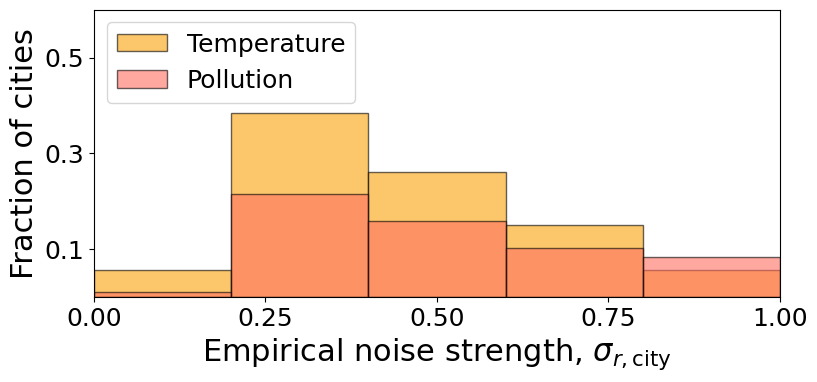

In [35]:
color_PM = "#ff6f61"
color_T  = "#faa307"

figsize=(8, 4)

plot_variable(
    np.array(σ_T),
    np.array(σ_PM),
    xmin=0, xmax=1,
    xlabel = r'Empirical noise strength, ${\sigma_{r,\mathrm{city}}}$', #^{x}
    filename='Sigma_climate.svg',
    step=0.2, #0.375
    bin_range=(0, 1),
    custom_xticks=np.arange(0, 1.01, 0.25)
)

### STREET NETWORK

In [19]:
os.chdir(r'C:\Users\mduran\Desktop\PhD- Patterns and Dynamics in Urban Networks\1- DATA POLLUTION - Scaling laws, pdfs\RESULTS_GLOBAL') 

node_color = "#c19ee0"

def plot_node_variable(data, xmin, xmax, xlabel, filename, step=None, num_bins=None, bin_range=None, custom_xticks=None):

    data_clean = data[~np.isnan(data) & ~np.isinf(data)]
    
    if bin_range is None:
        bin_range = (xmin, xmax)
        
    if step is not None:
        bins = np.arange(bin_range[0], bin_range[1] + step, step)
    else:
        if num_bins is None:
            num_bins = 10 
        bins = np.linspace(bin_range[0], bin_range[1], num_bins+1)
    
    if len(data_clean) == 0:
        data_clean = np.array([0.0])
    weights = np.ones_like(data_clean) / len(data_clean)
    
    figsize = (10, 6)
    plt.figure(figsize=figsize)

    plt.hist(data_clean, bins=bins, color=node_color, alpha=0.6, edgecolor='black', weights=weights, label='Street network')
    
    plt.xlabel(xlabel, fontsize=32)
    plt.ylabel('Fraction of cities', fontsize=32)
    plt.tick_params(axis='x', labelsize=28)
    plt.tick_params(axis='y', labelsize=28)
    
    plt.tight_layout()
    plt.xlim(xmin, xmax)
    plt.ylim(0, 0.8)
    plt.yticks([0, 0.2, 0.4, 0.6, 0.8])
    
    if custom_xticks is not None:
        plt.xticks(custom_xticks)

    # plt.legend(fontsize=26, loc='best')
        
    # plt.savefig(filename, format='svg', dpi=600, bbox_inches='tight')
    plt.show()


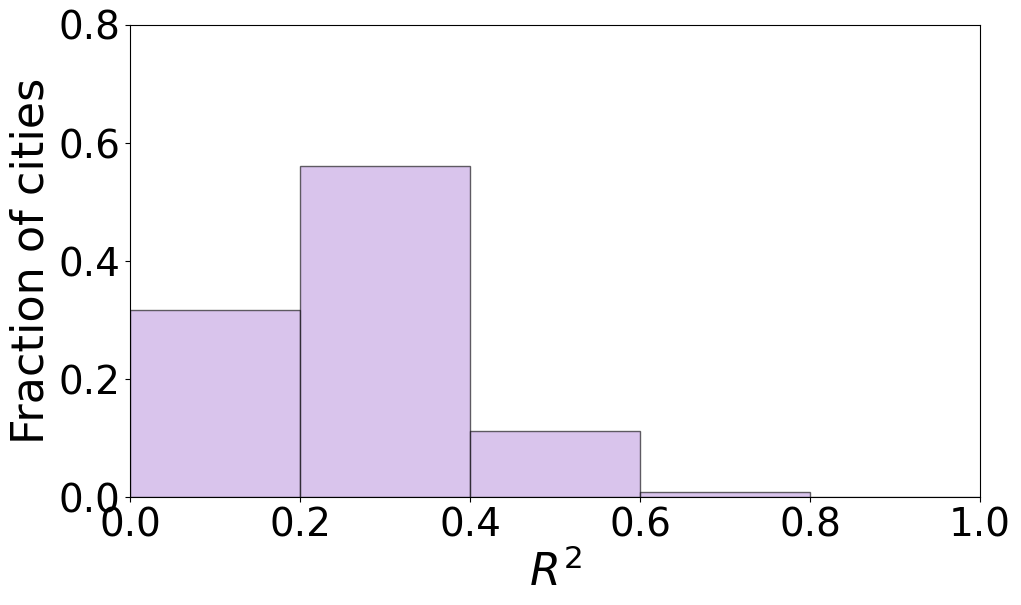

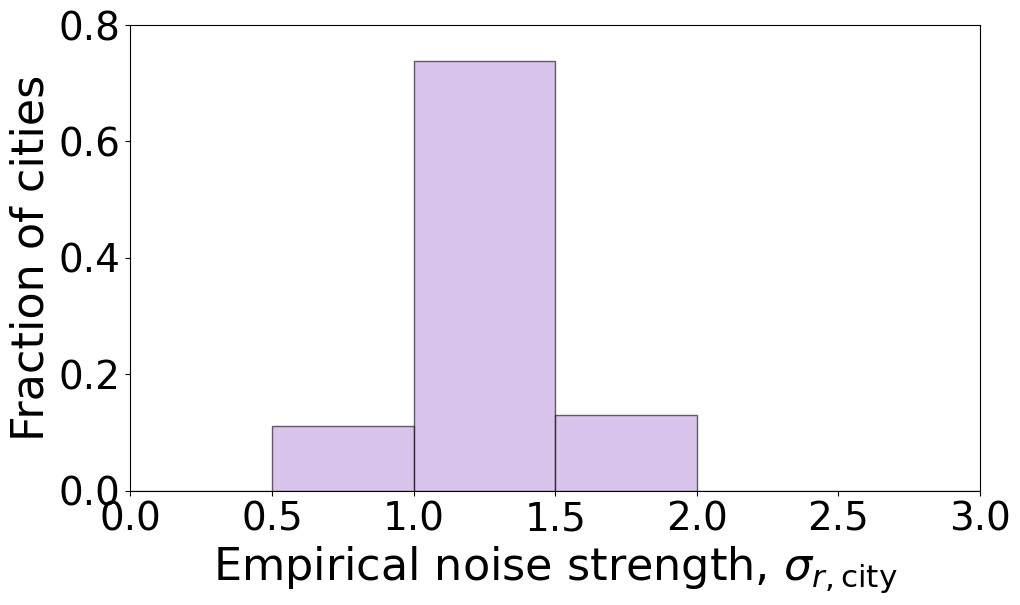

In [20]:
plot_node_variable(np.array(R2_node),
                   xmin=0, xmax=1,
                   xlabel=r'$R^2$',
                   filename='NodeR2.svg',
                   step=0.2)

plot_node_variable(np.array(σlog_node),
                   xmin=0., xmax=3,
                   xlabel=r'Empirical noise strength, $\sigma_{r,\mathrm{city}}$',
                   filename='Sigma_node.svg',
                   step=0.5)

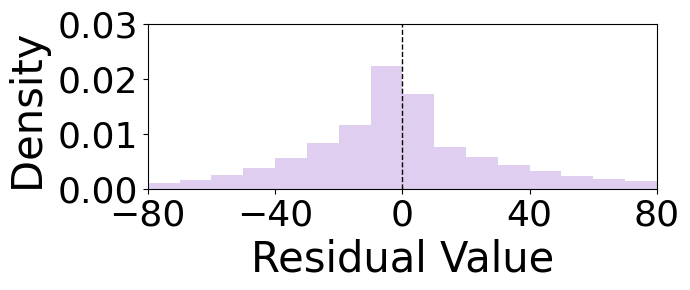

In [67]:
os.chdir(r'C:\Users\mduran\Desktop\PhD- Patterns and Dynamics in Urban Networks\1- DATA POLLUTION - Scaling laws, pdfs\RESULTS_GLOBAL') 

step = 10
bins = np.arange(-80, 80 + step, step)

plt.figure(figsize=(7, 3))

residuals_node_adj = residuals_node_all.copy()

plt.hist(residuals_node_adj,
         bins=bins,
         alpha=0.5,
         density=True,
         color='#c19ee0',
         label='Street network residuals')

plt.axvline(x=0, color='k', linestyle='--', linewidth=1)

plt.xlabel("Residual Value", fontsize=30)
plt.ylabel("Density ", fontsize=30)
plt.xlim(-80, 80)

plt.yticks([0, 0.01, 0.02, 0.03])
plt.xticks([-80, -40, 0, 40, 80])

plt.tick_params(axis='x', labelsize=26)
plt.tick_params(axis='y', labelsize=26)

plt.tight_layout()

# plt.savefig("decay_fit_residuals_node.svg", format="svg", dpi=600, bbox_inches="tight")

plt.show()

## PEARSON CORRELATIONS

0.8006127341019019 4.2493745891390975e-25 0.5511565956716419 4.915655823414385e-09 0.3379654592160051 0.00037051947105722256 0.38895453574331984 4.121367823402058e-05 0.0491977593341038 0.6182061163152459


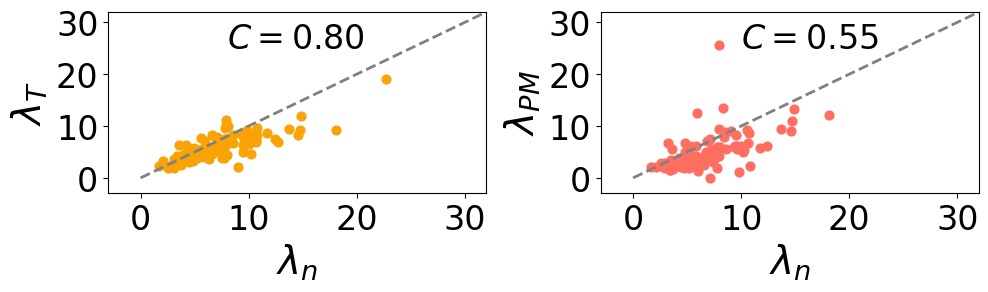

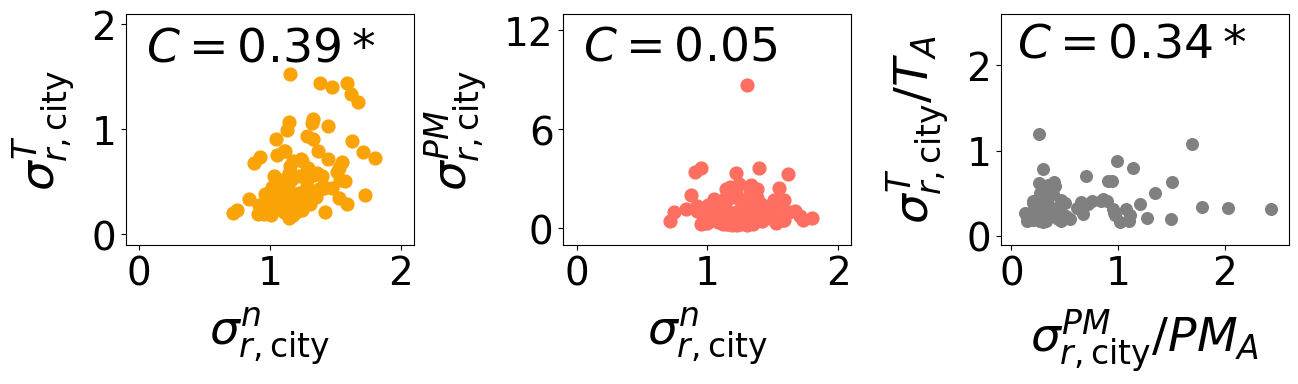

In [22]:
os.chdir(r'C:\Users\mduran\Desktop\PhD- Patterns and Dynamics in Urban Networks\1- DATA POLLUTION - Scaling laws, pdfs\RESULTS_GLOBAL') 

lam_node     = λ_node      # intersections decay rate
lam_T        = λ_T         # temperature decay rate
lam_PM       = λ_PM        # PM2.5 decay rate
cv_node      = σlog_node   # street network multiplicative CV
sigma_T_abs  = σ_T         # temperature absolute noise
sigma_PM_abs = σ_PM        # PM2.5 absolute noise

cv_node_plot   = cv_node.copy()        # σ_log-n
sigma_T_plot   = sigma_T_abs.copy()    # σ_T (°C)
sigma_PM_plot  = sigma_PM_abs.copy()   # σ_PM (μg/m³)
cv_T_plot   = sigma_T_abs/T0    # σ_T (°C)
cv_PM_plot  = sigma_PM_abs/PM0   # σ_PM (μg/m³)

mask_keep = cv_node_plot <= 3.5
cv_node_plot   = cv_node_plot[mask_keep]
sigma_T_plot   = sigma_T_plot[mask_keep]
sigma_PM_plot  = sigma_PM_plot[mask_keep]


mask1_plot = (~np.isnan(lam_node)) & (~np.isnan(lam_T)) & (lam_node > 0) & (lam_node < 100) & (lam_T > 0) & (lam_T < 100)
mask2_plot = (~np.isnan(lam_node)) & (~np.isnan(lam_PM)) & (lam_node > 0) & (lam_node < 100) & (lam_PM > 0) & (lam_PM < 100)
mask5_plot = ~np.isnan(cv_PM_plot) & ~np.isnan(cv_T_plot)
mask6_plot = ~np.isnan(cv_node_plot) & ~np.isnan(sigma_T_plot)
mask7_plot = ~np.isnan(cv_node_plot) & ~np.isnan(sigma_PM_plot)



r1, p1 = pearsonr(lam_node[mask1_plot], lam_T[mask1_plot])
r2, p2 = pearsonr(lam_node[mask2_plot], lam_PM[mask2_plot])
r5, p5 = pearsonr(cv_PM_plot[mask5_plot], cv_T_plot[mask5_plot])
r6, p6 = pearsonr(cv_node_plot[mask6_plot], sigma_T_plot[mask6_plot])
r7, p7 = pearsonr(cv_node_plot[mask7_plot], sigma_PM_plot[mask7_plot])

print(r1, p1, r2, p2, r5, p5, r6, p6, r7, p7)

color_T  = "#faa307"
color_PM = "#ff6f61"

# ----------------------------------------------------

maxλ  = np.nanmax([lam_node, lam_T, lam_PM])
xdiag = np.linspace(0, 40, 100)

lam_PM_plot = lam_PM.copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))
ax1.scatter(lam_node[mask1_plot], lam_T[mask1_plot], s=40, color=color_T)
ax1.plot(xdiag, xdiag, '--', color='gray', lw=2)
ax1.set_xlim(-3, 32)
ax1.set_ylim(-3, 32)
ax1.set_xlabel(r'$\lambda_{n}$', fontsize=28)
ax1.set_ylabel(r'$\lambda_{T}$', fontsize=28)
ax1.tick_params(axis='x', labelsize=24)
ax1.tick_params(axis='y', labelsize=24)
ax1.set_xticks([0, 10, 20, 30])
ax1.set_yticks([0, 10, 20, 30])
ax1.text(8, 25, rf'$C={r1:.2f}$', fontsize=24)

ax2.scatter(lam_node[mask2_plot], lam_PM_plot[mask2_plot], s=40, color=color_PM)
ax2.plot(xdiag, xdiag, '--', color='gray', lw=2)
ax2.set_xlim(-3, 32)
ax2.set_ylim(-3, 32)
ax2.set_xlabel(r'$\lambda_{n}$', fontsize=28)
ax2.set_ylabel(r'$\lambda_{PM}$', fontsize=28)
ax2.tick_params(axis='x', labelsize=24)
ax2.tick_params(axis='y', labelsize=24)
ax2.set_xticks([0, 10, 20, 30])
ax2.set_yticks([0, 10, 20, 30])
ax2.text(10, 25, rf'$C={r2:.2f}$', fontsize=24)

plt.tight_layout()

# plt.savefig('decay_params_comparison_node.svg', format='svg', dpi=600, bbox_inches='tight')

plt.show()

# ----------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 3), gridspec_kw={'wspace': 0.52})

# -------- Panel 1: sigma^n_r,city vs sigma^T_r,city --------
ax = axes[0]
ax.scatter(cv_node_plot[mask6_plot], sigma_T_plot[mask6_plot], s=85, color=color_T)
ax.set_xlabel(r'$\sigma^{n}_{r,\mathrm{city}}$', fontsize=34, labelpad=10)
ax.set_ylabel(r'$\sigma^{T}_{r,\mathrm{city}}$', fontsize=34, labelpad=10)
ax.set_xlim(-0.1, 2.1); ax.set_ylim(-0.1, 2.1)
ax.set_xticks([0, 1, 2]); ax.set_yticks([0, 1, 2])
ax.tick_params(axis='both', labelsize=28)
sig = "*" if p6 < 1e-3 else ""
ax.text(0.05, 1.65, rf'$C={r6:.2f}{sig}$', fontsize=34)

# -------- Panel 2: sigma^n_r,city vs sigma^PM_r,city --------
ax = axes[1]
ax.scatter(cv_node_plot[mask7_plot], sigma_PM_plot[mask7_plot], s=85, color=color_PM)
ax.set_xlabel(r'$\sigma^{n}_{r,\mathrm{city}}$', fontsize=34, labelpad=10)
ax.set_ylabel(r'$\sigma^{PM}_{r,\mathrm{city}}$', fontsize=34, labelpad=10)
ax.set_xlim(-0.1, 2.1); ax.set_ylim(-1, 13)
ax.set_xticks([0, 1, 2]); ax.set_yticks([0, 6, 12])
ax.tick_params(axis='both', labelsize=28)
sig = "*" if p7 < 1e-3 else ""
ax.text(0.05, 10.2, rf'$C={r7:.2f}{sig}$', fontsize=34)

# -------- Panel 3: normalized climate noise CV --------
ax = axes[2]
ax.scatter(cv_PM_plot[mask5_plot], cv_T_plot[mask5_plot], s=70, color='grey')
ax.set_xlabel(r'$\sigma^{PM}_{r,\mathrm{city}}/PM_{A}$', fontsize=34, labelpad=10)
ax.set_ylabel(r'$\sigma^{T}_{r,\mathrm{city}}/T_{A}$', fontsize=34, labelpad=10)
ax.set_xlim(-0.1, 2.6); ax.set_ylim(-0.1, 2.6)
ax.set_xticks([0, 1, 2]); ax.set_yticks([0, 1, 2])
ax.tick_params(axis='both', labelsize=28)
sig = "*" if p5 < 1e-3 else ""
ax.text(0.05, 2.1, rf'$C={r5:.2f}{sig}$', fontsize=34)

plt.tight_layout()
# plt.savefig('noise_params_threepanel.svg', format='svg', dpi=600, bbox_inches='tight')
plt.show()